In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [5]:
#Battery charging model
def battery_charge( Dch, P_max,SOC):

    P_BES_pos =(P_max/(1-Dch))*(SOC-1)
    if P_BES_pos < -P_max:
        P_BES_pos = -P_max
    return P_BES_pos


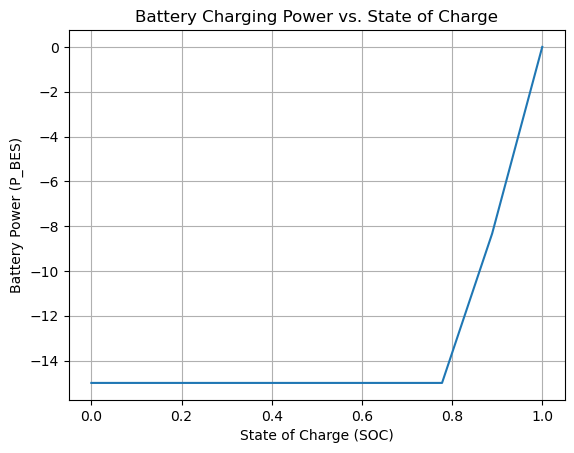

In [6]:
SOC = np.linspace(0,1,10)
Dch = 0.8
P_max = 15
P_BES_pos = []
for i in range(len(SOC)):
    P_BES_pos.append(battery_charge(Dch, P_max, SOC[i]))

plt.plot(SOC, P_BES_pos)
plt.xlabel("State of Charge (SOC)")
plt.ylabel("Battery Power (P_BES)")
plt.title("Battery Charging Power vs. State of Charge")
plt.grid(True)
plt.show()

In [ ]:
#Battery discharging model
def battery_discharge( Ddis, P_rated,SOC):

    P_BES_disch =(P_rated/(Ddis))*(SOC)
    if P_BES_disch > P_rated:
        P_BES_disch = P_rated
    return P_BES_disch

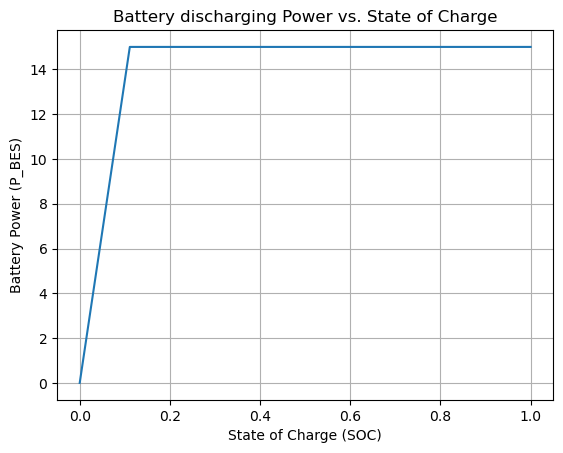

In [7]:

Ddis = 0.1
P_BES_neg = []
for i in range(len(SOC)):
    P_BES_neg.append(battery_discharge(Ddis, P_max, SOC[i]))

plt.plot(SOC, P_BES_neg)
plt.xlabel("State of Charge (SOC)")
plt.ylabel("Battery Power (P_BES)")
plt.title("Battery discharging Power vs. State of Charge")
plt.grid(True)
plt.show()

In [9]:
def batter_power(nch,ndch,P_pos,P_neg):
    p_bat = nch*P_pos - (1/ndch)*P_neg
    return p_bat

In [10]:
def energy_battery(E_bes, P_bat, time_step):
    E_bes_new = E_bes + P_bat * time_step
    return E_bes_new

In [ ]:
def SOC_battery(E_bes, E_bes_lim):
    SOC = E_bes / E_bes_lim
    return SOC

In [12]:
def Energy_limit(E_lim, DEbes):
    E_lim_new = E_lim - DEbes
    return E_lim_new

In [13]:
#delta energy battery ehich shos the capacity lost during this step
def DEbes_battery(a,P_bat, time_step):
    DEbes = a*abs(P_bat) * time_step
    return DEbes

In [14]:
#Delta PV
def delta_PV(PV_fc, PV_actual):
    delta_PV = PV_actual - PV_fc
    return delta_PV

In [15]:
#Delta EV
def delta_EV(EV_fc, EV_actual):
    delta_EV = EV_actual - EV_fc
    return delta_EV

In [17]:
def p_error(delta_PV, delta_EV):
    p_error = delta_EV - delta_PV
    return p_error